## GUINNESS STOCK PRICE PREDICTION

In [1]:
## to change the name across the code
## ctrl + h will open the tab the fill the new name in replace
## to change the name across the entire code so you dont have to click enter everytime
## ctrl + shift + h

import pandas as pd

guinness=pd.read_csv('../stock_data/guinness.csv') ## so it can be small letter. This is cool.
guinness=guinness.drop(columns=['high_price','low_price'])
guinness.rename(columns={'trade_date':'date'},inplace=True)
guinness['date']=pd.to_datetime(guinness['date'])
guinness['month']=guinness['date'].dt.month
guinness['quarter']=guinness['date'].dt.quarter
guinness['year']=guinness['date'].dt.year

guinness

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year
0,42789,GUINNESS,2017-01-03,83.05,83.05,36010,2026-04-08T02:41:25.765521+00:00,1,1,2017
1,43349,GUINNESS,2017-01-04,83.05,83.05,109028,2026-04-08T02:42:20.164398+00:00,1,1,2017
2,43459,GUINNESS,2017-01-05,78.90,78.90,415432,2026-04-08T02:42:22.380516+00:00,1,1,2017
3,43569,GUINNESS,2017-01-06,80.00,80.00,61549,2026-04-08T02:42:23.84796+00:00,1,1,2017
4,43659,GUINNESS,2017-01-09,80.00,80.00,78415,2026-04-08T02:42:26.938159+00:00,1,1,2017
...,...,...,...,...,...,...,...,...,...,...
2258,298069,GUINNESS,2026-07-13,329.00,329.00,333582,2026-07-13T15:10:02.995074+00:00,7,3,2026
2259,298507,GUINNESS,2026-07-14,329.00,329.00,256827,2026-07-14T15:10:03.094441+00:00,7,3,2026
2260,298945,GUINNESS,2026-07-15,329.00,329.00,99813,2026-07-15T15:10:03.078609+00:00,7,3,2026
2261,299383,GUINNESS,2026-07-16,329.00,329.00,606832,2026-07-16T15:10:03.113936+00:00,7,3,2026


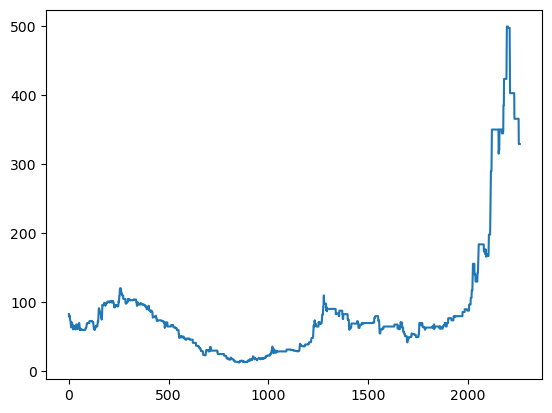

In [2]:
import matplotlib.pyplot as plt

plt.plot(guinness['close_price'])
plt.show()

In [3]:
guinness_end_month_df = (
    guinness
    .sort_values("date")
    .groupby(guinness["date"].dt.to_period("M"))
    .tail(1)
    .reset_index(drop=True)
)

guinness_end_month_df

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year
0,45359,GUINNESS,2017-01-31,64.15,64.15,2029352,2026-04-08T02:43:03.07753+00:00,1,1,2017
1,47180,GUINNESS,2017-02-28,65.35,65.35,1720957,2026-04-08T02:44:45.006295+00:00,2,1,2017
2,49296,GUINNESS,2017-03-31,60.51,60.51,352272,2026-04-08T02:45:42.281198+00:00,3,1,2017
3,51124,GUINNESS,2017-04-28,60.01,60.01,3806401,2026-04-08T02:51:55.619599+00:00,4,2,2017
4,53046,GUINNESS,2017-05-31,71.00,71.00,919675,2026-04-08T02:52:57.421655+00:00,5,2,2017
...,...,...,...,...,...,...,...,...,...,...
110,35307,GUINNESS,2026-03-31,423.20,423.20,86446,2026-03-31T15:00:02.085058+00:00,3,1,2026
111,281133,GUINNESS,2026-04-30,497.00,497.00,22849,2026-04-30T15:00:02.170664+00:00,4,2,2026
112,284199,GUINNESS,2026-05-29,402.60,402.60,51136,2026-05-29T15:00:02.455558+00:00,5,2,2026
113,294127,GUINNESS,2026-06-30,365.50,365.50,63637,2026-06-30T15:10:03.08168+00:00,6,2,2026


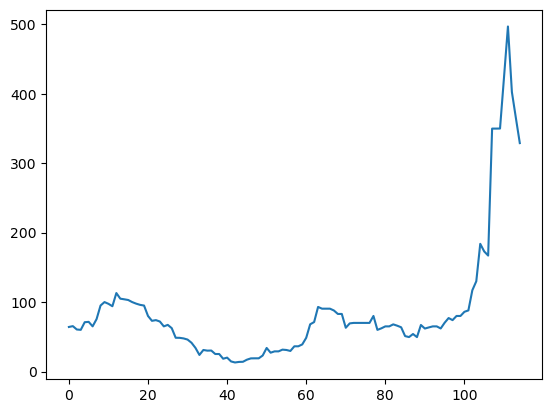

In [4]:
plt.plot(guinness_end_month_df['close_price'])
plt.show()

In [5]:
guinness_end_month_df['returns']=guinness_end_month_df['close_price'].pct_change()*100
guinness_end_month_df

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year,returns
0,45359,GUINNESS,2017-01-31,64.15,64.15,2029352,2026-04-08T02:43:03.07753+00:00,1,1,2017,NaN
1,47180,GUINNESS,2017-02-28,65.35,65.35,1720957,2026-04-08T02:44:45.006295+00:00,2,1,2017,1.870616
2,49296,GUINNESS,2017-03-31,60.51,60.51,352272,2026-04-08T02:45:42.281198+00:00,3,1,2017,-7.406274
3,51124,GUINNESS,2017-04-28,60.01,60.01,3806401,2026-04-08T02:51:55.619599+00:00,4,2,2017,-0.826310
4,53046,GUINNESS,2017-05-31,71.00,71.00,919675,2026-04-08T02:52:57.421655+00:00,5,2,2017,18.313614
...,...,...,...,...,...,...,...,...,...,...,...
110,35307,GUINNESS,2026-03-31,423.20,423.20,86446,2026-03-31T15:00:02.085058+00:00,3,1,2026,20.914286
111,281133,GUINNESS,2026-04-30,497.00,497.00,22849,2026-04-30T15:00:02.170664+00:00,4,2,2026,17.438563
112,284199,GUINNESS,2026-05-29,402.60,402.60,51136,2026-05-29T15:00:02.455558+00:00,5,2,2026,-18.993964
113,294127,GUINNESS,2026-06-30,365.50,365.50,63637,2026-06-30T15:10:03.08168+00:00,6,2,2026,-9.215102


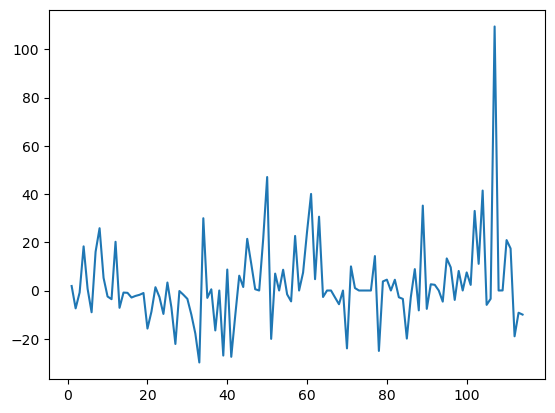

In [6]:
plt.plot(guinness_end_month_df['returns'])
plt.show()

In [7]:
## Test stationarity

from statsmodels.tsa.stattools import adfuller

result = adfuller(guinness_end_month_df['returns'].dropna())
print(result)
pvalue = result[1]
if pvalue < 0.05:
    print('stationary')
else:
    print('not stationary')

(-3.3507949834581865, 0.012755096521113113, 3, 110, {'1%': -3.4912451337340342, '5%': -2.8881954545454547, '10%': -2.5809876033057852}, 862.809874528174)
stationary


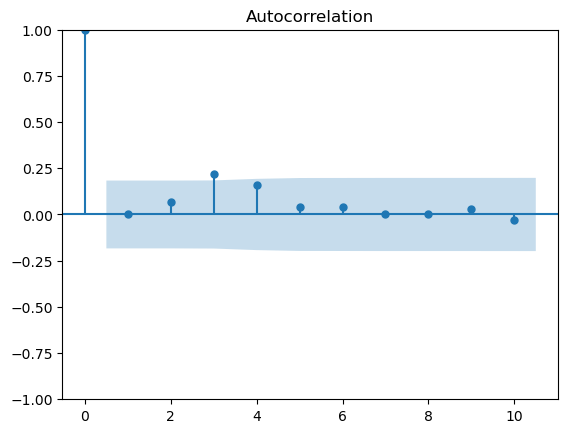

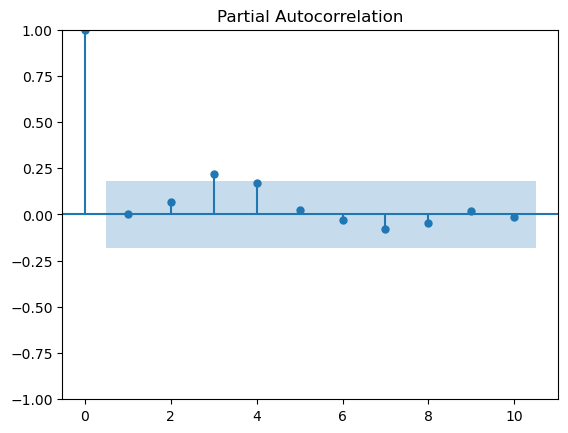

In [8]:
# Plotting the autocorrelation function and the partial autocorrelation function
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(guinness_end_month_df['returns'].dropna(), lags=10)
plot_pacf(guinness_end_month_df['returns'].dropna(), lags=10)
plt.show()

In [9]:
import random
random.seed(12345)

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

train=guinness_end_month_df['close_price'][:-10]
test=guinness_end_month_df['close_price'][-10:]

# Grid Search on the SARIMA model
import numpy as np
scores = []
for p in range(3):
    for i in range(3):
        for q in range(3):
            for P in range(3):
                for D in range(3):
                    for Q in range(3):
                        try:
                            mod = SARIMAX(train, 
                            order=(p,i,q), seasonal_order=(P,D,Q,12))
                            res = mod.fit(disp=False)
                            fcst=res.forecast(steps=10)
                            score =  [p,i,q,P,D,Q,r2_score(test,fcst)]
                            print(score)
                            scores.append(score)
                            del mod
                            del res
                        except:
                            print('errored')


[0, 0, 0, 0, 0, 0, -12.298292588797626]
[0, 0, 0, 0, 0, 1, -9.556777937983748]
[0, 0, 0, 0, 0, 2, -7.016683282142621]
[0, 0, 0, 0, 1, 0, -7.108876956095932]
[0, 0, 0, 0, 1, 1, -6.812384066873658]
[0, 0, 0, 0, 1, 2, -7.50787047018671]
[0, 0, 0, 0, 2, 0, -5.894865495105826]
[0, 0, 0, 0, 2, 1, -7.001212820482261]
[0, 0, 0, 0, 2, 2, -6.31339874734018]
[0, 0, 0, 1, 0, 0, -7.551187147944875]
[0, 0, 0, 1, 0, 1, -7.185562754962275]
[0, 0, 0, 1, 0, 2, -7.619227381152717]
[0, 0, 0, 1, 1, 0, -7.108924622608207]
[0, 0, 0, 1, 1, 1, -7.193230939139633]
[0, 0, 0, 1, 1, 2, -7.547676547732131]
[0, 0, 0, 1, 2, 0, -6.154611447007875]
[0, 0, 0, 1, 2, 1, -6.739230400365321]
[0, 0, 0, 1, 2, 2, -6.757955344752032]
[0, 0, 0, 2, 0, 0, -7.5105784055634714]
[0, 0, 0, 2, 0, 1, -7.672168652610933]
[0, 0, 0, 2, 0, 2, -7.921817535571721]
[0, 0, 0, 2, 1, 0, -6.583626591485436]
[0, 0, 0, 2, 1, 1, -6.599592927601944]
[0, 0, 0, 2, 1, 2, -5.660298740515186]
[0, 0, 0, 2, 2, 0, -5.922710855557855]
[0, 0, 0, 2, 2, 1, -5.805

In [10]:
res = pd.DataFrame(scores)
res.columns = ['p', 'i', 'q', 'P', 'D', 'Q', 'score']
result = res.sort_values('score')
result

,p,i,q,P,D,Q,score
0,0,0,0,0,0,0,-12.298293
27,0,0,1,0,0,0,-12.017029
54,0,0,2,0,0,0,-11.732344
1,0,0,0,0,0,1,-9.556778
55,0,0,2,0,0,1,-9.448034
...,...,...,...,...,...,...,...
226,0,2,2,1,0,1,0.379816
236,0,2,2,2,0,2,0.384430
704,2,2,2,0,0,2,0.385956
434,1,2,1,0,0,2,0.386823


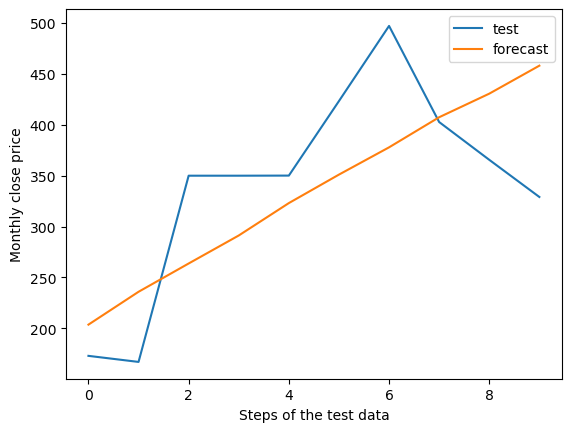

r2_score:  0.38963819063835203
rmse:  75.90139753227996
description:  count    115.000000
mean      86.709913
std       88.423706
min       13.000000
25%       43.700000
50%       67.000000
75%       89.250000
max      497.000000
Name: close_price, dtype: float64


In [11]:
# Fitting a SARIMAX model with our best model 
# order=(2,0,1), seasonal_order=(1,2,1,10)

import random
random.seed(12345)
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

y_train=guinness_end_month_df['close_price'][:-10]
y_test=guinness_end_month_df['close_price'][-10:]

# scaler=StandardScaler()
# exog_train_scaled=scaler.fit_transform(X_full[:-10])
# exog_test_scaled=scaler.transform(X_full[-10:])

mod = SARIMAX(
y_train,
order=(2,2,1), 
seasonal_order=(0,0,2,12),
)

res = mod.fit(disp=False)
fcst = res.forecast(steps=10)

plt.plot(list(y_test))
plt.plot(list(fcst))
plt.xlabel('Steps of the test data')
plt.ylabel('Monthly close price')
plt.legend(['test', 'forecast'])
plt.show()
print('r2_score: ',r2_score(y_test, fcst))
print('rmse: ', np.sqrt(mean_squared_error(y_test,fcst)))
print('description: ', guinness_end_month_df.close_price.describe())

Its not capturing the variations properly. Lets try the returns

In [12]:
import random
random.seed(12345)

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

train=guinness_end_month_df['returns'].dropna()[:-10]
test=guinness_end_month_df['returns'].dropna()[-10:]

# Grid Search on the SARIMA model
import numpy as np
scores = []
for p in range(3):
    for i in range(3):
        for q in range(3):
            for P in range(3):
                for D in range(3):
                    for Q in range(3):
                        try:
                            mod = SARIMAX(train, 
                            order=(p,i,q), seasonal_order=(P,D,Q,12))
                            res = mod.fit(disp=False)
                            fcst=res.forecast(steps=10)
                            score =  [p,i,q,P,D,Q,r2_score(test,fcst)]
                            print(score)
                            scores.append(score)
                            del mod
                            del res
                        except:
                            print('errored')


[0, 0, 0, 0, 0, 0, -0.0816581732806454]
[0, 0, 0, 0, 0, 1, -0.052788862353125854]
[0, 0, 0, 0, 0, 2, -0.07045117210406993]
[0, 0, 0, 0, 1, 0, -0.018746845230608322]
[0, 0, 0, 0, 1, 1, -0.05183814253427399]
[0, 0, 0, 0, 1, 2, -0.012989940566755065]
[0, 0, 0, 0, 2, 0, -0.3916012807570577]
[0, 0, 0, 0, 2, 1, -0.008862681169525821]
[0, 0, 0, 0, 2, 2, 0.024960518514238084]
[0, 0, 0, 1, 0, 0, -0.06541948687650989]
[0, 0, 0, 1, 0, 1, -0.045082491628040566]
[0, 0, 0, 1, 0, 2, -0.11716145016934387]
[0, 0, 0, 1, 1, 0, -0.027230276178920265]
[0, 0, 0, 1, 1, 1, -0.026409391790733983]
[0, 0, 0, 1, 1, 2, -0.010884330008014809]
[0, 0, 0, 1, 2, 0, -0.2777140418490509]
[0, 0, 0, 1, 2, 1, -0.0032182450086517544]
[0, 0, 0, 1, 2, 2, -0.009784008014873447]
[0, 0, 0, 2, 0, 0, -0.05695343898184779]
[0, 0, 0, 2, 0, 1, -0.13336460544798667]
[0, 0, 0, 2, 0, 2, -0.11844801714945641]
[0, 0, 0, 2, 1, 0, 0.06450961589581317]
[0, 0, 0, 2, 1, 1, -0.019974606177248777]
[0, 0, 0, 2, 1, 2, -0.03763160049780789]
[0, 0, 0

In [13]:
res = pd.DataFrame(scores)
res.columns = ['p', 'i', 'q', 'P', 'D', 'Q', 'score']
result = res.sort_values('score')
result

,p,i,q,P,D,Q,score
166,0,2,0,0,1,1,-48.536477
168,0,2,0,0,2,0,-48.260550
184,0,2,0,2,1,1,-47.759021
167,0,2,0,0,1,2,-47.186380
176,0,2,0,1,1,2,-47.101993
...,...,...,...,...,...,...,...
323,1,0,2,2,2,2,0.109813
538,2,0,1,2,2,1,0.133613
534,2,0,1,2,1,0,0.137917
322,1,0,2,2,2,1,0.141211


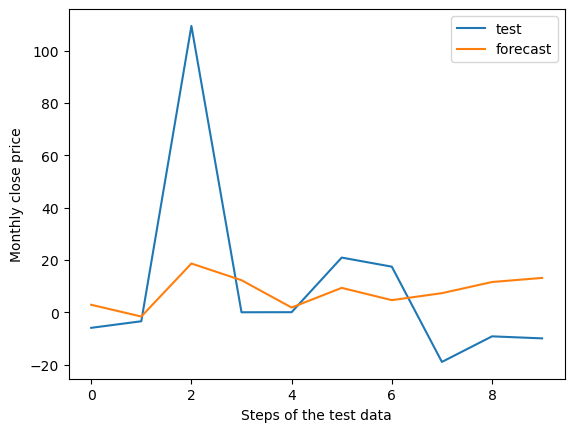

r2_score:  0.15197848541131687
rmse:  32.326458473259
description:  count    114.000000
mean       2.690208
std       17.351674
min      -29.852941
25%       -3.821986
50%        0.000000
75%        7.484504
max      109.520958
Name: returns, dtype: float64


In [14]:
# Fitting a SARIMAX model with our best model 
# order=(2,0,1), seasonal_order=(1,2,1,10)

import random
random.seed(12345)
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

y_train=guinness_end_month_df['returns'].dropna()[:-10]
y_test=guinness_end_month_df['returns'].dropna()[-10:]

# scaler=StandardScaler()
# exog_train_scaled=scaler.fit_transform(X_full[:-10])
# exog_test_scaled=scaler.transform(X_full[-10:])

mod = SARIMAX(
y_train,
order=(1,0,2), 
seasonal_order=(2,1,0,12),
)

res = mod.fit(disp=False)
fcst = res.forecast(steps=10)

plt.plot(list(y_test))
plt.plot(list(fcst))
plt.xlabel('Steps of the test data')
plt.ylabel('Monthly close price')
plt.legend(['test', 'forecast'])
plt.show()
print('r2_score: ',r2_score(y_test, fcst))
print('rmse: ', np.sqrt(mean_squared_error(y_test,fcst)))
print('description: ', guinness_end_month_df.returns.dropna().describe())

Still not good enough.
